In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('Data/staff_turnover_cleaned.csv')
df.head()

,EmpID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,EducationField,EnvironmentSatisfaction,Gender,JobRole,...,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM650,53,No,Travel_Rarely,Research & Development,23,Life Sciences,4,Female,Research Director,...,18,3,3,33,0,3,12,9,3,8.0
1,RM015,28,Yes,Travel_Rarely,Research & Development,24,Life Sciences,3,Male,Laboratory Technician,...,14,3,2,6,4,3,4,2,0,3.0
2,RM1111,35,Yes,Travel_Rarely,Research & Development,2,Life Sciences,1,Female,Laboratory Technician,...,12,3,4,1,2,3,1,0,0,0.0
3,RM1438,39,No,Non_Travel,Research & Development,9,Life Sciences,4,Male,Manager,...,13,3,3,21,3,2,6,0,1,3.0
4,RM311,31,No,Travel_Rarely,Human Resources,2,Human Resources,1,Male,Human Resources,...,12,3,4,9,1,3,2,2,1,0.0


In [10]:
df_jobrole_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack()
df_jobrole_attrition = df_jobrole_attrition[['Yes']].style.format("{:.1%}")
df_jobrole_attrition

Attrition,Yes
JobRole,
Healthcare Representative,6.9%
Human Resources,23.1%
Laboratory Technician,24.0%
Manager,4.9%
Manufacturing Director,6.9%
Research Director,2.5%
Research Scientist,16.0%
Sales Executive,17.5%
Sales Representative,39.8%


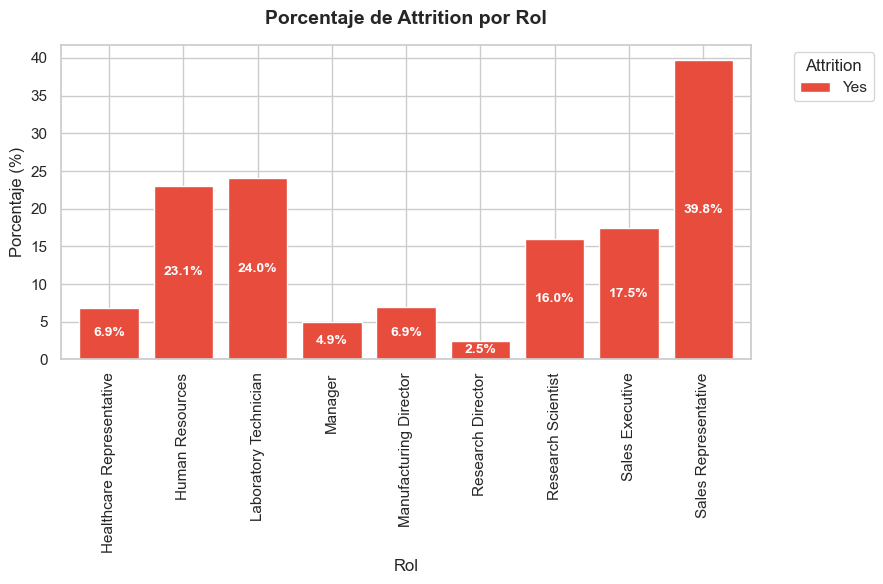

In [11]:
df_jobrole_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100
df_jobrole_attrition = df_jobrole_attrition[['Yes']]
ax = df_jobrole_attrition.plot(kind='bar', stacked=True, color=['#e74c3c'], figsize=(9, 6), width=.8)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Rol', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rol', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=90) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


The sales representative role shows the highest attrition rate among the various roles, whereas the research scientist role shows an attrition rate of only 2.5%. We can categorize the roles into three main groups based on attrition:
1. Sales Representative
2. Human Resources, Laboratory Technician, Research Scientist, and Sales Executive.
3. Healthcare Representative, Manager, Manufacturing Director, and Research Director.

This raises the following questions:

How do the working conditions of sales representatives compare to those of research scientists?

What are the possible factors that directly influence attrition?

In [5]:
df_Age_Salary_attrition = df[['Age', 'MonthlyIncome', 'Attrition']]
df_Age_Salary_attrition=df_Age_Salary_attrition[df_Age_Salary_attrition['Attrition'] == 'Yes']
df_Age_Salary_attrition

,Age,MonthlyIncome,Attrition
1,28,2028,Yes
2,35,2074,Yes
6,30,2422,Yes
10,29,5765,Yes
18,33,5324,Yes
...,...,...,...
1444,49,4284,Yes
1445,28,9854,Yes
1449,40,13194,Yes
1456,28,2515,Yes


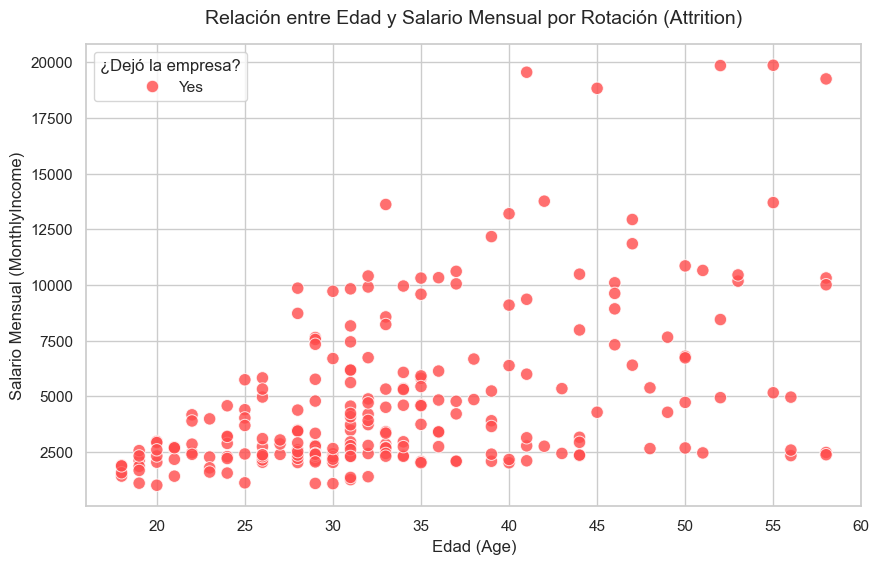

In [ ]:

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_Age_Salary_attrition,
    x="Age",
    y="MonthlyIncome",
    hue="Attrition",
    palette={"Yes": "#FF4B4B", "No": "#1F77B4"},  # Rojo para Yes, Azul para No
    alpha=0.8,  # Hace los puntos un poco transparentes si se enciman
    s=80,  # Tamaño de los puntos
)

# 4. Personalizamos los textos del gráfico
plt.title(
    "Relación entre Años en la Empresa y Años en el Puesto por Rotación (Attrition)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Años en la Empresa", fontsize=12)
plt.ylabel("Años en el Puesto", fontsize=12)

# 5. Ajustamos la leyenda para que se vea ordenada
plt.legend(title="¿Dejó la empresa?")

# 6. Mostramos el gráfico en pantalla
plt.show()
